# Celestial Body Temperature Profile Analysis #

### Imports ###

In [12]:
import krpc
import numpy as np
import matplotlib.pyplot as plt

### Connect to kRPC Server ###

In [2]:
conn = krpc.connect(name='KRPC Test')
print(conn.krpc.get_status().version)
vessel = conn.space_center.active_vessel
kerbin = conn.space_center.bodies['Kerbin']
celest_refframe = kerbin.non_rotating_reference_frame
vessel_refframe = vessel.reference_frame
session = (conn, vessel, celest_refframe)

0.5.4


### Collect Data ###

In [8]:
nsamples = 5000
max_altitude = 100 # km
altitudes = np.linspace(0, max_altitude*1000, nsamples)

lat = vessel.flight(celest_refframe).latitude
lng = vessel.flight(celest_refframe).longitude

temperatures = np.empty(nsamples)
for i, alt in enumerate(altitudes):
    pos = kerbin.position_at_altitude(lat, lng, alt, celest_refframe)
    temperatures[i] = kerbin.temperature_at(pos, celest_refframe)


### Reduce Data ###

In [92]:

def reduce_data(altitude, temperature):
    if len(altitude) < 3:
        return altitude, temperature

    reduced_altitude = [altitude[0]]
    reduced_temperature = [temperature[0]]

    for i in range(1, len(altitude) - 1):
        # Calculate the direction of the temperature change
        # dir1 = np.sign(temperature[i] - temperature[i - 1])
        # dir2 = np.sign(temperature[i + 1] - temperature[i])

        dir1 = np.array([altitude[i] - altitude[i-1], temperature[i] - temperature[i-1]])
        dir1 /= np.linalg.norm(dir1)
        dir2 = np.array([altitude[i+1] - altitude[i], temperature[i+1] - temperature[i]])
        dir2 /= np.linalg.norm(dir2)

        # Keep the point if the direction changes
        if not np.allclose(dir1, dir2, atol=1.5e-5):
            reduced_altitude.append(altitude[i])
            reduced_temperature.append(temperature[i])

    reduced_altitude.append(altitude[-1])
    reduced_temperature.append(temperature[-1])
    
    len_alt = len(altitude)
    len_red_alt = len(reduced_altitude)
    print(f'Reduced data from {len_alt} elements to {len_red_alt} ({100*(len_alt-len_red_alt)/len_alt:.2f}%)')

    return np.array(reduced_altitude), np.array(reduced_temperature)

In [93]:
reduced_altitudes, reduced_temperatures = reduce_data(altitudes, temperatures)

Reduced data from 5000 elements to 137 (97.26%)


### Plot Data ###

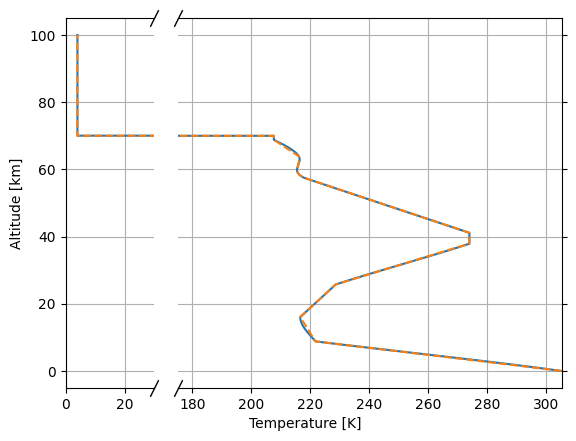

In [94]:
break_start = 30
break_end = 175

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [break_start-0, np.max(temperatures)-break_end]})

# Plot the data on both subplots
ax1.plot(temperatures, altitudes/1000)
ax2.plot(temperatures, altitudes/1000)
ax1.plot(reduced_temperatures, reduced_altitudes/1000, linestyle='--')
ax2.plot(reduced_temperatures, reduced_altitudes/1000, linestyle='--')

# Set the x-axis limits for the first subplot (before the break)
ax1.set_xlim(0, break_start)
# Set the x-axis limits for the second subplot (after the break)
ax2.set_xlim(break_end, np.max(temperatures))

# Hide the spines between ax1 and ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.yaxis.tick_left()
ax2.tick_params(labelright=False)
ax2.yaxis.tick_right()

d = 0.5
kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([1, 1], [1, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)


# Set labels and grid
fig.supxlabel("Temperature [K]", y=0.02, size=10)
ax1.set_ylabel("Altitude [km]")
ax1.grid()
ax2.grid()

# Adjust the space between subplots
plt.subplots_adjust(wspace=0.1)
plt.show()

### Save Data ###

In [96]:
data_to_save = np.column_stack((reduced_altitudes, reduced_temperatures))
filename = "temperature.csv"
header_string = "altitude,temperature"
np.savetxt(filename,
           data_to_save,
           delimiter=",",
           header=header_string,
           comments="This file contains the temperature vs. altitude curve for Kerbin. Altitude in meters and temperature in K.")

print(f"Successfully saved data to '{filename}'")

Successfully saved data to 'temperature.csv'
